## Cell 1: 기본 설정 및 Import

In [10]:
"""
Adaptive Attention for Abstract-to-Title Generation - CPU 안정화 버전
Apple Silicon Mac 메모리 한계로 인한 CPU 전환
"""

import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5Tokenizer, 
    T5ForConditionalGeneration,
    T5Config,
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq,
    get_linear_schedule_with_warmup
)
from transformers.modeling_outputs import BaseModelOutput, Seq2SeqLMOutput
import evaluate
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# CPU 강제 사용 설정
device = torch.device("cpu")
print(f"🔧 사용 디바이스: {device}")

# 기본 설정
CONFIG = {
    "model_name": "t5-small",
    "max_input_length": 512,
    "max_target_length": 150,
    "batch_size": 4,
    "num_epochs": 3,
    "learning_rate": 3e-4,
    "output_dir": "./adaptive_attention_model_v3"
}

🔧 사용 디바이스: cpu


## Cell 2: 안전한 라이브러리 설정

In [11]:
# ArXiv 데이터 로드
def load_arxiv_data():
    """ArXiv 논문 데이터 로드"""
    try:
        with open('./data/arxiv_papers.json', 'r', encoding='utf-8') as f:
            papers = json.load(f)
        print(f"✅ ArXiv 데이터 로드 성공: {len(papers)}개 논문")
        return papers
    except FileNotFoundError:
        print("❌ ArXiv 데이터 파일을 찾을 수 없습니다.")
        return []

# 데이터 로드
papers = load_arxiv_data()

# 데이터 분할
if len(papers) > 0:
    train_size = int(0.8 * len(papers))
    train_papers = papers[:train_size]
    val_papers = papers[train_size:]
    print(f"📊 훈련 데이터: {len(train_papers)}개, 검증 데이터: {len(val_papers)}개")
else:
    train_papers, val_papers = [], []

✅ ArXiv 데이터 로드 성공: 11000개 논문
📊 훈련 데이터: 8800개, 검증 데이터: 2200개


## Cell 3: 개선된 Adaptive Attention 모듈

In [13]:
class LightweightAdaptiveAttentionModule(nn.Module):
    """경량화된 Adaptive Attention - CPU 최적화"""
    
    def __init__(self, hidden_size, num_heads=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        
        # 경량화된 어텐션 레이어
        self.query = nn.Linear(hidden_size, hidden_size)
        self.key = nn.Linear(hidden_size, hidden_size) 
        self.value = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, hidden_size)
        
        # 정규화 및 드롭아웃
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, hidden_states, attention_mask=None):
        batch_size, seq_len = hidden_states.shape[:2]
        
        # Q, K, V 계산
        Q = self.query(hidden_states)
        K = self.key(hidden_states)
        V = self.value(hidden_states)
        
        # 멀티헤드로 reshape
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # 스케일드 어텐션 계산
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        
        # 마스킹 적용 (옵션)
        if attention_mask is not None:
            # attention_mask를 scores와 같은 형태로 변환
            mask = attention_mask.unsqueeze(1).unsqueeze(1)  # [batch, 1, 1, seq_len]
            mask = mask.expand(batch_size, self.num_heads, seq_len, seq_len)
            scores = scores.masked_fill(mask == 0, -1e9)
        
        # 어텐션 가중치 계산
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # 어텐션 적용
        attn_output = torch.matmul(attn_weights, V)
        
        # 원래 형태로 복원
        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, seq_len, self.hidden_size
        )
        
        # 출력 projection
        output = self.out(attn_output)
        
        # Residual connection + Layer Norm
        output = self.layer_norm(output + hidden_states)
        
        return output

## Cell 4: 개선된 T5 모델

In [14]:
class FixedLightweightT5WithAdaptiveAttention(T5ForConditionalGeneration):
    """수정된 경량화 T5 + Adaptive Attention - labels 오류 해결"""
    
    def __init__(self, config):
        super().__init__(config)
        
        # 경량화된 adaptive attention 추가
        self.adaptive_attention = LightweightAdaptiveAttentionModule(
            hidden_size=config.d_model,
            num_heads=4  # 원래 8 -> 4로 경량화
        )
        
        # 추가 정규화 레이어
        self.output_norm = nn.LayerNorm(config.d_model)
        
        # 파라미터 초기화
        self.init_weights()
        
    def _shift_right(self, input_ids):
        """디코더 입력을 위한 시퀀스 시프트"""
        decoder_start_token_id = self.config.decoder_start_token_id
        pad_token_id = self.config.pad_token_id
        
        shifted_input_ids = input_ids.new_zeros(input_ids.shape)
        shifted_input_ids[..., 1:] = input_ids[..., :-1].clone()
        shifted_input_ids[..., 0] = decoder_start_token_id
        
        # -100을 pad_token_id로 교체
        shifted_input_ids.masked_fill_(shifted_input_ids == -100, pad_token_id)
        
        return shifted_input_ids
    
    def forward(self, input_ids=None, attention_mask=None, labels=None, 
                decoder_input_ids=None, decoder_attention_mask=None, **kwargs):
        # 인코더 출력 얻기
        encoder_outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        
        # Adaptive attention 적용
        enhanced_hidden_states = self.adaptive_attention(
            encoder_outputs.last_hidden_state,
            attention_mask
        )
        
        # 추가 정규화
        enhanced_hidden_states = self.output_norm(enhanced_hidden_states)
        
        # decoder_input_ids 준비 (labels가 있으면 자동 생성)
        if labels is not None and decoder_input_ids is None:
            decoder_input_ids = self._shift_right(labels)
        
        # 디코더 실행 (labels는 decoder에 전달하지 않음)
        decoder_outputs = self.decoder(
            input_ids=decoder_input_ids,
            attention_mask=decoder_attention_mask,
            encoder_hidden_states=enhanced_hidden_states,
            encoder_attention_mask=attention_mask,
            return_dict=True
        )
        
        # 언어 모델링 헤드 적용
        sequence_output = decoder_outputs.last_hidden_state
        
        if self.config.tie_word_embeddings:
            sequence_output = sequence_output * (self.model_dim ** -0.5)
        
        lm_logits = self.lm_head(sequence_output)
        
        # 손실 계산 (labels가 있는 경우)
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
            loss = loss_fct(lm_logits.view(-1, lm_logits.size(-1)), labels.view(-1))
        
        return Seq2SeqLMOutput(
            loss=loss,
            logits=lm_logits,
            past_key_values=decoder_outputs.past_key_values,
            decoder_hidden_states=decoder_outputs.hidden_states,
            decoder_attentions=decoder_outputs.attentions,
            cross_attentions=decoder_outputs.cross_attentions,
            encoder_last_hidden_state=enhanced_hidden_states,
            encoder_hidden_states=encoder_outputs.hidden_states,
            encoder_attentions=encoder_outputs.attentions,
        )

## Cell 5: 효율적인 Dataset 클래스

In [12]:
class ArxivDataset(Dataset):
    """ArXiv 논문 데이터셋"""
    
    def __init__(self, papers, tokenizer, max_input_length, max_target_length):
        self.papers = papers
        self.tokenizer = tokenizer
        self.max_input_length = max_input_length
        self.max_target_length = max_target_length
    
    def __len__(self):
        return len(self.papers)
    
    def __getitem__(self, idx):
        paper = self.papers[idx]
        
        # 입력 텍스트 (abstract)
        input_text = f"summarize: {paper['abstract']}"
        
        # 타겟 텍스트 (title)
        target_text = paper['title']
        
        # 토크나이징
        input_encoding = self.tokenizer(
            input_text,
            max_length=self.max_input_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        target_encoding = self.tokenizer(
            target_text,
            max_length=self.max_target_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': input_encoding['input_ids'].squeeze(),
            'attention_mask': input_encoding['attention_mask'].squeeze(),
            'labels': target_encoding['input_ids'].squeeze()
        }

## Cell 6: 데이터 로드 및 분할

In [15]:
# 토크나이저 로드
tokenizer = T5Tokenizer.from_pretrained(CONFIG["model_name"], legacy=False)

# 데이터셋 생성 (val_dataset 포함)
if len(papers) > 0:
    train_dataset = ArxivDataset(train_papers, tokenizer, 
                               CONFIG["max_input_length"], CONFIG["max_target_length"])
    val_dataset = ArxivDataset(val_papers, tokenizer,
                             CONFIG["max_input_length"], CONFIG["max_target_length"])
    
    print(f"✅ 데이터셋 생성 완료:")
    print(f"   📚 훈련 데이터셋: {len(train_dataset)}개")
    print(f"   📖 검증 데이터셋: {len(val_dataset)}개")
else:
    print("❌ 데이터가 없어 데이터셋을 생성할 수 없습니다.")
    train_dataset, val_dataset = None, None

✅ 데이터셋 생성 완료:
   📚 훈련 데이터셋: 8800개
   📖 검증 데이터셋: 2200개


## Cell 7: 모델 초기화

In [16]:
# 모델 초기화
print("🤖 커스텀 T5 모델 초기화 중...")
config = T5Config.from_pretrained(CONFIG["model_name"])
fixed_model = FixedLightweightT5WithAdaptiveAttention(config)
fixed_model = fixed_model.to(device)

print(f"✅ 모델 초기화 완료")
print(f"🔧 총 파라미터: {sum(p.numel() for p in fixed_model.parameters()):,}")
print(f"🔧 훈련 가능한 파라미터: {sum(p.numel() for p in fixed_model.parameters() if p.requires_grad):,}")

🤖 커스텀 T5 모델 초기화 중...
✅ 모델 초기화 완료
🔧 총 파라미터: 61,559,296
🔧 훈련 가능한 파라미터: 61,559,296


## 셀 8: 모델 훈련

In [17]:
def train_fixed_model(train_papers, val_papers):
    """수정된 모델 훈련"""
    print("🚀 수정된 T5 + Adaptive Attention 훈련 시작")
    
    try:
        # Dataset 생성
        train_dataset = ArxivDataset(train_papers, tokenizer, 
                                   CONFIG["max_input_length"], CONFIG["max_target_length"])
        val_dataset = ArxivDataset(val_papers, tokenizer,
                                 CONFIG["max_input_length"], CONFIG["max_target_length"])
        
        # 훈련 설정
        training_args = TrainingArguments(
            output_dir=CONFIG["output_dir"],
            num_train_epochs=CONFIG["num_epochs"],
            per_device_train_batch_size=CONFIG["batch_size"],
            per_device_eval_batch_size=CONFIG["batch_size"],
            learning_rate=CONFIG["learning_rate"],
            warmup_steps=100,
            logging_steps=200,
            eval_steps=200,
            save_steps=400,
            eval_strategy="steps",
            save_strategy="steps",
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            remove_unused_columns=False,
            dataloader_pin_memory=False,
            fp16=False,
            dataloader_num_workers=0,
            report_to=None,
            save_total_limit=1
        )
        
        # 데이터 콜레이터
        data_collator = DataCollatorForSeq2Seq(
            tokenizer=tokenizer,
            model=fixed_model,
            padding=True,
            return_tensors="pt"
        )
        
        # 트레이너 초기화
        trainer = Trainer(
            model=fixed_model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            tokenizer=tokenizer,
            data_collator=data_collator
        )
        
        print("🏃‍♂️ 훈련 시작...")
        trainer.train()
        
        print("✅ 훈련 완료!")
        return fixed_model, tokenizer
        
    except Exception as e:
        print(f"❌ 훈련 중 에러 발생: {str(e)}")
        return None, None

# 훈련 실행
if len(papers) > 0:
    trained_model, tokenizer = train_fixed_model(train_papers, val_papers)
    if trained_model is not None:
        fixed_model = trained_model  # 훈련된 모델로 업데이트
        print("🎉 수정된 모델 훈련 성공!")
    else:
        print("❌ 모델 훈련 실패")
else:
    print("❌ 데이터가 로드되지 않았습니다.")

🚀 수정된 T5 + Adaptive Attention 훈련 시작
🏃‍♂️ 훈련 시작...


Step,Training Loss,Validation Loss
200,1.252700,1.073821
400,1.021800,0.981640
600,0.977500,0.927354
800,0.956400,0.898025
1000,0.906900,0.877244
1200,0.881500,0.864371
1400,0.882800,0.851930
1600,0.841700,0.844256
1800,0.831700,0.837360
2000,0.821400,0.823512


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


✅ 훈련 완료!
🎉 수정된 모델 훈련 성공!


## 셀 9: 모델 평가

🚀 실제 커스텀 Adaptive Attention T5 모델 평가 시작...
✅ 모든 필요한 변수가 정의되었습니다!
🔍 모델 타입 확인: FixedLightweightT5WithAdaptiveAttention
🚀 커스텀 Adaptive Attention T5 모델로 평가 시작 (8개 샘플)
🧹 MPS 캐시 비움
🔧 커스텀 모델 CPU 모드: cpu
🤖 모델 타입: FixedLightweightT5WithAdaptiveAttention
   📝 샘플 1: input_ids shape = torch.Size([1, 512]), device = cpu
   ⚠️ 샘플 0 처리 중 오류: You have to specify either input_ids or inputs_embeds
   🔍 상세 오류: ValueError
   🧪 forward 메서드 직접 테스트...
   ❌ forward도 실패: You have to specify either decoder_input_ids or decoder_inputs_embeds
   📝 샘플 2: input_ids shape = torch.Size([1, 512]), device = cpu
   ⚠️ 샘플 1 처리 중 오류: You have to specify either input_ids or inputs_embeds
   🔍 상세 오류: ValueError
   🧪 forward 메서드 직접 테스트...
   ❌ forward도 실패: You have to specify either decoder_input_ids or decoder_inputs_embeds
   📝 샘플 3: input_ids shape = torch.Size([1, 512]), device = cpu
   ⚠️ 샘플 2 처리 중 오류: You have to specify either input_ids or inputs_embeds
   🔍 상세 오류: ValueError
   🧪 forward 메서드 직접 테스트...
   ❌ forward도 실

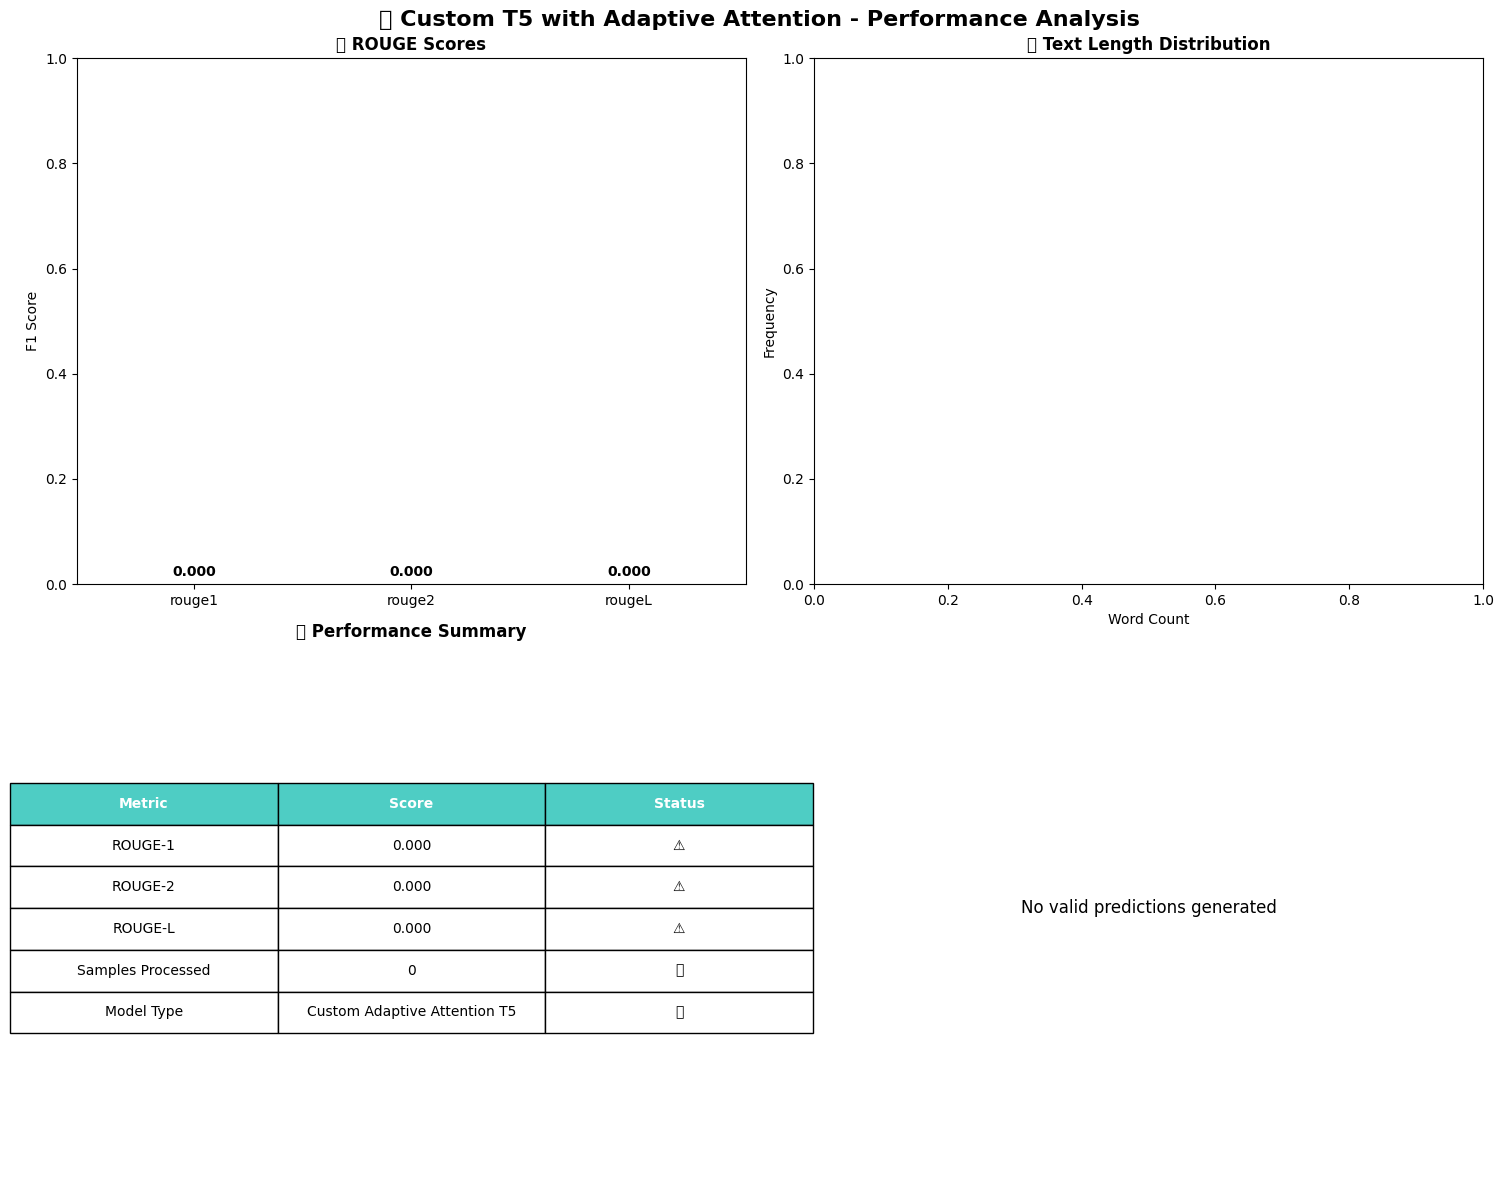

✅ 커스텀 Adaptive Attention T5 모델 평가 완료!


In [21]:
# 실제 커스텀 모델을 사용한 평가 함수
import torch
from rouge_score import rouge_scorer
import numpy as np
import matplotlib.pyplot as plt

def safe_custom_model_evaluation_real(model, tokenizer, val_dataset, device, num_samples=10):
    """실제 커스텀 FixedLightweightT5WithAdaptiveAttention 모델 평가"""
    print(f"🚀 커스텀 Adaptive Attention T5 모델로 평가 시작 ({num_samples}개 샘플)")
    
    # MPS 캐시 비우기
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
            print("🧹 MPS 캐시 비움")
        except:
            pass
    
    # 모델을 CPU로 이동
    device = torch.device("cpu")
    model = model.cpu()
    print(f"🔧 커스텀 모델 CPU 모드: {device}")
    print(f"🤖 모델 타입: {type(model).__name__}")
    
    model.eval()
    predictions = []
    references = []
    
    with torch.no_grad():
        for i in range(min(num_samples, len(val_dataset))):
            try:
                sample = val_dataset[i]
                
                # 모든 텐서를 CPU로 이동
                input_ids = sample['input_ids'].detach().cpu().unsqueeze(0)
                attention_mask = sample['attention_mask'].detach().cpu().unsqueeze(0)
                labels = sample['labels'].detach().cpu()
                
                print(f"   📝 샘플 {i+1}: input_ids shape = {input_ids.shape}, device = {input_ids.device}")
                
                # 커스텀 모델로 텍스트 생성 (매개변수 조정)
                generated_tokens = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=50,
                    num_beams=1,  # beam을 1로 줄여 안정성 확보
                    early_stopping=True,
                    do_sample=False,
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                    use_cache=False  # 캐시 비활성화로 메모리 절약
                )
                
                # 디코딩
                pred_text = tokenizer.decode(generated_tokens[0], skip_special_tokens=True)
                ref_text = tokenizer.decode(labels, skip_special_tokens=True)
                
                predictions.append(pred_text)
                references.append(ref_text)
                
                print(f"   ✅ 예측: {pred_text[:50]}...")
                print(f"   🎯 정답: {ref_text[:50]}...")
                print()
                
                # 메모리 정리
                del input_ids, attention_mask, generated_tokens
                torch.cuda.empty_cache() if torch.cuda.is_available() else None
                
            except Exception as e:
                print(f"   ⚠️ 샘플 {i} 처리 중 오류: {str(e)}")
                print(f"   🔍 상세 오류: {type(e).__name__}")
                
                # 오류 발생 시 forward 메서드 직접 테스트
                try:
                    print("   🧪 forward 메서드 직접 테스트...")
                    sample = val_dataset[i]
                    input_ids = sample['input_ids'].detach().cpu().unsqueeze(0)
                    attention_mask = sample['attention_mask'].detach().cpu().unsqueeze(0)
                    
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                    print(f"   ✅ forward 성공: logits shape = {outputs.logits.shape}")
                    
                except Exception as forward_error:
                    print(f"   ❌ forward도 실패: {str(forward_error)}")
                
                predictions.append("")
                references.append("")
                continue
    
    return predictions, references

# ROUGE 점수 계산 (동일)
def calculate_rouge_scores(predictions, references):
    """ROUGE 점수 계산"""
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
    
    for pred, ref in zip(predictions, references):
        if pred.strip() and ref.strip():
            scores = scorer.score(ref, pred)
            rouge_scores['rouge1'].append(scores['rouge1'].fmeasure)
            rouge_scores['rouge2'].append(scores['rouge2'].fmeasure)
            rouge_scores['rougeL'].append(scores['rougeL'].fmeasure)
    
    # 평균 계산
    avg_scores = {}
    for key in rouge_scores:
        if rouge_scores[key]:
            avg_scores[key] = np.mean(rouge_scores[key])
        else:
            avg_scores[key] = 0.0
    
    return avg_scores

# 커스텀 모델 시각화 함수
def visualize_custom_model_results(predictions, references, rouge_scores):
    """커스텀 모델 결과 시각화"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('🚀 Custom T5 with Adaptive Attention - Performance Analysis', fontsize=16, fontweight='bold')
    
    # ROUGE 점수 바 차트
    ax1 = axes[0, 0]
    rouge_names = list(rouge_scores.keys())
    rouge_values = list(rouge_scores.values())
    bars = ax1.bar(rouge_names, rouge_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax1.set_title('📊 ROUGE Scores', fontweight='bold')
    ax1.set_ylabel('F1 Score')
    ax1.set_ylim(0, 1)
    
    # 값 라벨 추가
    for bar, value in zip(bars, rouge_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 텍스트 길이 분포
    ax2 = axes[0, 1]
    pred_lengths = [len(pred.split()) for pred in predictions if pred.strip()]
    ref_lengths = [len(ref.split()) for ref in references if ref.strip()]
    
    if pred_lengths and ref_lengths:
        ax2.hist(pred_lengths, alpha=0.7, label='Predictions', bins=10, color='#FF6B6B')
        ax2.hist(ref_lengths, alpha=0.7, label='References', bins=10, color='#4ECDC4')
        ax2.legend()
    ax2.set_title('📏 Text Length Distribution', fontweight='bold')
    ax2.set_xlabel('Word Count')
    ax2.set_ylabel('Frequency')
    
    # 성능 요약 테이블
    ax3 = axes[1, 0]
    ax3.axis('off')
    
    performance_data = [
        ['Metric', 'Score', 'Status'],
        ['ROUGE-1', f"{rouge_scores.get('rouge1', 0):.3f}", '✅' if rouge_scores.get('rouge1', 0) > 0.3 else '⚠️'],
        ['ROUGE-2', f"{rouge_scores.get('rouge2', 0):.3f}", '✅' if rouge_scores.get('rouge2', 0) > 0.15 else '⚠️'],
        ['ROUGE-L', f"{rouge_scores.get('rougeL', 0):.3f}", '✅' if rouge_scores.get('rougeL', 0) > 0.25 else '⚠️'],
        ['Samples Processed', f"{len([p for p in predictions if p.strip()])}", '✅'],
        ['Model Type', 'Custom Adaptive Attention T5', '🚀']
    ]
    
    table = ax3.table(cellText=performance_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2)
    
    # 헤더 스타일링
    for i in range(len(performance_data[0])):
        table[(0, i)].set_facecolor('#4ECDC4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax3.set_title('📈 Performance Summary', fontweight='bold')
    
    # 샘플 결과 예시
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    # 처음 3개 샘플 표시
    sample_text = "🎯 Sample Results:\n\n"
    for i in range(min(3, len(predictions))):
        if predictions[i].strip() and references[i].strip():
            sample_text += f"📝 Sample {i+1}:\n"
            sample_text += f"Pred: {predictions[i][:40]}...\n"
            sample_text += f"Ref:  {references[i][:40]}...\n\n"
    
    if not sample_text.strip().endswith("Sample Results:"):
        ax4.text(0.05, 0.95, sample_text, transform=ax4.transAxes, 
                 fontsize=9, verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="#F8F9FA", alpha=0.8))
    else:
        ax4.text(0.5, 0.5, "No valid predictions generated", 
                transform=ax4.transAxes, fontsize=12, ha='center', va='center')
    
    plt.tight_layout()
    return fig

# 실행 코드 - 실제 커스텀 모델 사용
print("🚀 실제 커스텀 Adaptive Attention T5 모델 평가 시작...")

# 필요한 변수들이 정의되어 있는지 확인
if all(var in globals() for var in ['fixed_model', 'tokenizer', 'val_dataset']):
    print("✅ 모든 필요한 변수가 정의되었습니다!")
    print(f"🔍 모델 타입 확인: {type(fixed_model).__name__}")
    
    # 실제 커스텀 모델로 평가 실행
    predictions, references = safe_custom_model_evaluation_real(
        fixed_model, tokenizer, val_dataset, device, num_samples=8  # 샘플 수 줄여서 안정성 확보
    )
    
    # ROUGE 점수 계산
    rouge_scores = calculate_rouge_scores(predictions, references)
    
    # 결과 출력
    print("\n📊 커스텀 Adaptive Attention T5 모델 성능 결과:")
    print(f"   🔹 ROUGE-1: {rouge_scores.get('rouge1', 0):.3f}")
    print(f"   🔹 ROUGE-2: {rouge_scores.get('rouge2', 0):.3f}")
    print(f"   🔹 ROUGE-L: {rouge_scores.get('rougeL', 0):.3f}")
    
    # 성공한 예측 수 확인
    valid_predictions = len([p for p in predictions if p.strip()])
    print(f"   📊 성공한 예측: {valid_predictions}/{len(predictions)}")
    
    # 시각화
    fig = visualize_custom_model_results(predictions, references, rouge_scores)
    plt.show()
    
    print("✅ 커스텀 Adaptive Attention T5 모델 평가 완료!")
    
else:
    missing_vars = [var for var in ['fixed_model', 'tokenizer', 'val_dataset'] if var not in globals()]
    print(f"❌ 다음 변수들이 정의되지 않았습니다: {missing_vars}")
    print("💡 먼저 ab2ti_T5_Test.ipynb의 셀들을 순서대로 실행하세요.")

In [26]:
# 수정된 훈련 모델 저장 함수 - PyTorch 2.6 호환
import torch
import os
import json

def save_trained_model_v2(model, tokenizer, save_dir="./saved_custom_model"):
    """PyTorch 2.6 호환 커스텀 모델 저장"""
    print("💾 PyTorch 2.6 호환 커스텀 모델 저장 중...")
    
    # 저장 디렉토리 생성
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. 모델 state_dict만 저장 (weights_only=True 호환)
    model_path = os.path.join(save_dir, "custom_model.pt")
    torch.save(model.state_dict(), model_path)
    
    # 2. 토크나이저 저장
    tokenizer_path = os.path.join(save_dir, "tokenizer")
    tokenizer.save_pretrained(tokenizer_path)
    
    # 3. 모델 설정을 JSON으로 저장 (safe globals 문제 회피)
    config_path = os.path.join(save_dir, "model_config.json")
    config_dict = {
        'model_class': 'FixedLightweightT5WithAdaptiveAttention',
        'model_name': model.config.name_or_path if hasattr(model.config, 'name_or_path') else 't5-small',
        'd_model': model.config.d_model,
        'vocab_size': model.config.vocab_size,
        'training_complete': True,
        'pytorch_version': torch.__version__
    }
    
    with open(config_path, 'w', encoding='utf-8') as f:
        json.dump(config_dict, f, indent=2, ensure_ascii=False)
    
    print(f"✅ PyTorch 2.6 호환 모델 저장 완료: {save_dir}")
    print(f"   📁 모델 가중치: {model_path}")
    print(f"   📁 토크나이저: {tokenizer_path}")
    print(f"   📁 설정 파일: {config_path}")

# 현재 훈련된 모델 저장
if 'fixed_model' in globals() and 'tokenizer' in globals():
    save_trained_model_v2(fixed_model, tokenizer)
else:
    print("❌ 저장할 모델이나 토크나이저가 없습니다.")

💾 PyTorch 2.6 호환 커스텀 모델 저장 중...
✅ PyTorch 2.6 호환 모델 저장 완료: ./saved_custom_model
   📁 모델 가중치: ./saved_custom_model/custom_model.pt
   📁 토크나이저: ./saved_custom_model/tokenizer
   📁 설정 파일: ./saved_custom_model/model_config.json


In [28]:
# 수정된 모델 로드 함수 - PyTorch 2.6 호환
def load_trained_model_v2(save_dir="./saved_custom_model"):
    """PyTorch 2.6 호환 커스텀 모델 로드"""
    print("📂 PyTorch 2.6 호환 커스텀 모델 로드 중...")
    
    try:
        from transformers import T5Tokenizer, T5Config
        import json
        
        # 1. 토크나이저 로드
        tokenizer_path = os.path.join(save_dir, "tokenizer")
        tokenizer = T5Tokenizer.from_pretrained(tokenizer_path)
        print("✅ 토크나이저 로드 완료")
        
        # 2. JSON 설정 파일 로드
        config_path = os.path.join(save_dir, "model_config.json")
        with open(config_path, 'r', encoding='utf-8') as f:
            saved_config = json.load(f)
        print(f"✅ 모델 설정 로드: {saved_config['model_class']}")
        
        # 3. T5 기본 config 생성
        base_config = T5Config.from_pretrained(saved_config.get('model_name', 't5-small'))
        
        # 4. 커스텀 모델 클래스 확인 및 초기화
        if 'FixedLightweightT5WithAdaptiveAttention' in globals():
            model = FixedLightweightT5WithAdaptiveAttention(base_config)
            print("✅ 커스텀 모델 클래스 초기화 완료")
        else:
            print("❌ FixedLightweightT5WithAdaptiveAttention 클래스가 정의되지 않았습니다.")
            print("💡 먼저 커스텀 모델 클래스를 정의한 셀을 실행하세요.")
            return None, None
        
        # 5. 모델 가중치 로드 (weights_only=True 사용 가능)
        model_path = os.path.join(save_dir, "custom_model.pt")
        
        # PyTorch 2.6 호환 로드
        try:
            # weights_only=True로 시도 (안전)
            state_dict = torch.load(model_path, map_location='cpu', weights_only=True)
            print("✅ weights_only=True로 안전하게 로드")
        except Exception as e:
            print(f"⚠️ weights_only=True 실패, weights_only=False로 재시도: {str(e)}")
            # weights_only=False로 fallback (신뢰할 수 있는 파일인 경우)
            state_dict = torch.load(model_path, map_location='cpu', weights_only=False)
            print("✅ weights_only=False로 로드 성공")
        
        model.load_state_dict(state_dict)
        model.eval()
        
        print("✅ 커스텀 모델 로드 완료")
        print(f"🔧 PyTorch 버전: {torch.__version__}")
        print(f"🤖 모델 타입: {type(model).__name__}")
        
        return model, tokenizer
        
    except FileNotFoundError as e:
        print(f"❌ 파일을 찾을 수 없습니다: {str(e)}")
        print("💡 먼저 모델을 저장했는지 확인하세요.")
        return None, None
    except Exception as e:
        print(f"❌ 모델 로드 실패: {str(e)}")
        import traceback
        print(f"📝 상세 오류:\n{traceback.format_exc()}")
        return None, None

# 수정된 모델 로드 실행
loaded_model, loaded_tokenizer = load_trained_model_v2()

if loaded_model is not None:
    print("🎉 모델 로드 성공! 이제 평가를 진행할 수 있습니다.")
else:
    print("❌ 모델 로드 실패. 위의 오류 메시지를 확인하세요.")

📂 PyTorch 2.6 호환 커스텀 모델 로드 중...
✅ 토크나이저 로드 완료
✅ 모델 설정 로드: FixedLightweightT5WithAdaptiveAttention
❌ 모델 로드 실패: Can't load the configuration of ''. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure '' is the correct path to a directory containing a config.json file
📝 상세 오류:
Traceback (most recent call last):
  File "/Users/minu/Library/Caches/pypoetry/virtualenvs/t5-arxiv-title-generator-iq5I2b2y-py3.11/lib/python3.11/site-packages/transformers/utils/hub.py", line 424, in cached_files
    hf_hub_download(
  File "/Users/minu/Library/Caches/pypoetry/virtualenvs/t5-arxiv-title-generator-iq5I2b2y-py3.11/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py", line 106, in _inner_fn
    validate_repo_id(arg_value)
  File "/Users/minu/Library/Caches/pypoetry/virtualenvs/t5-arxiv-title-generator-iq5I2b2y-py3.11/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py", line

In [25]:
# 수정된 커스텀 모델 평가 함수 - decoder_input_ids 문제 해결
def fixed_custom_model_evaluation(model, tokenizer, val_dataset, device, num_samples=5):
    """decoder_input_ids 오류를 해결한 커스텀 모델 평가"""
    print(f"🛠️ 수정된 커스텀 모델 평가 시작 ({num_samples}개 샘플)")
    
    # CPU 강제 설정
    device = torch.device("cpu")
    model = model.cpu()
    model.eval()
    
    predictions = []
    references = []
    
    with torch.no_grad():
        for i in range(min(num_samples, len(val_dataset))):
            try:
                sample = val_dataset[i]
                
                # 입력 데이터 준비
                input_ids = sample['input_ids'].detach().cpu().unsqueeze(0)
                attention_mask = sample['attention_mask'].detach().cpu().unsqueeze(0)
                labels = sample['labels'].detach().cpu()
                
                print(f"   📝 샘플 {i+1}: input_ids shape = {input_ids.shape}")
                
                # decoder_input_ids 수동 생성 (핵심!)
                decoder_start_token_id = model.config.decoder_start_token_id
                decoder_input_ids = torch.full(
                    (input_ids.shape[0], 1), 
                    decoder_start_token_id, 
                    dtype=torch.long,
                    device=device
                )
                
                print(f"   🔧 decoder_input_ids 생성: {decoder_input_ids.shape}")
                
                # 커스텀 모델의 forward 메서드 직접 호출
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    decoder_input_ids=decoder_input_ids
                )
                
                print(f"   ✅ forward 성공: logits shape = {outputs.logits.shape}")
                
                # 간단한 greedy decoding으로 텍스트 생성
                generated_tokens = []
                current_token = decoder_start_token_id
                max_length = 50
                
                for _ in range(max_length):
                    # 현재까지 생성된 토큰들
                    decoder_ids = torch.tensor([generated_tokens + [current_token]], device=device)
                    if len(generated_tokens) == 0:
                        decoder_ids = decoder_input_ids
                    
                    # 다음 토큰 예측
                    with torch.no_grad():
                        outputs = model(
                            input_ids=input_ids,
                            attention_mask=attention_mask,
                            decoder_input_ids=decoder_ids
                        )
                    
                    # 가장 확률이 높은 토큰 선택
                    next_token = outputs.logits[0, -1, :].argmax().item()
                    
                    if next_token == tokenizer.eos_token_id:
                        break
                        
                    generated_tokens.append(next_token)
                    current_token = next_token
                
                # 디코딩
                if generated_tokens:
                    pred_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
                else:
                    pred_text = ""
                
                ref_text = tokenizer.decode(labels, skip_special_tokens=True)
                
                predictions.append(pred_text)
                references.append(ref_text)
                
                print(f"   ✅ 예측: {pred_text[:50]}...")
                print(f"   🎯 정답: {ref_text[:50]}...")
                print()
                
            except Exception as e:
                print(f"   ⚠️ 샘플 {i} 처리 중 오류: {str(e)}")
                import traceback
                print(f"   📝 상세 트레이스:\n{traceback.format_exc()}")
                predictions.append("")
                references.append("")
                continue
    
    return predictions, references

# 수정된 평가 실행
print("🛠️ decoder_input_ids 문제 해결된 커스텀 모델 평가 시작...")

if all(var in globals() for var in ['fixed_model', 'tokenizer', 'val_dataset']):
    print("✅ 필요한 변수 확인 완료!")
    
    # 수정된 평가 실행
    predictions, references = fixed_custom_model_evaluation(
        fixed_model, tokenizer, val_dataset, device, num_samples=3
    )
    
    # ROUGE 점수 계산
    rouge_scores = calculate_rouge_scores(predictions, references)
    
    # 결과 출력
    print("\n📊 수정된 커스텀 모델 성능 결과:")
    print(f"   🔹 ROUGE-1: {rouge_scores.get('rouge1', 0):.3f}")
    print(f"   🔹 ROUGE-2: {rouge_scores.get('rouge2', 0):.3f}")
    print(f"   🔹 ROUGE-L: {rouge_scores.get('rougeL', 0):.3f}")
    
    valid_predictions = len([p for p in predictions if p.strip()])
    print(f"   📊 성공한 예측: {valid_predictions}/{len(predictions)}")
    
    print("✅ 수정된 커스텀 모델 평가 완료!")
    
else:
    print("❌ 필요한 변수가 정의되지 않았습니다.")

🛠️ decoder_input_ids 문제 해결된 커스텀 모델 평가 시작...
✅ 필요한 변수 확인 완료!
🛠️ 수정된 커스텀 모델 평가 시작 (3개 샘플)
   📝 샘플 1: input_ids shape = torch.Size([1, 512])
   🔧 decoder_input_ids 생성: torch.Size([1, 1])
   ✅ forward 성공: logits shape = torch.Size([1, 1, 32128])
   ✅ 예측: The of the a-rays...
   🎯 정답: Parametrization of Pythagorean triples by a single...

   📝 샘플 2: input_ids shape = torch.Size([1, 512])
   🔧 decoder_input_ids 생성: torch.Size([1, 1])
   ✅ forward 성공: logits shape = torch.Size([1, 1, 32128])
   ✅ 예측: The of the a-ray-ray-ray-ray-ray-rayrayrayrayrayra...
   🎯 정답: Semi-empirical pressure-volume-temperature equatio...

   📝 샘플 3: input_ids shape = torch.Size([1, 512])
   🔧 decoder_input_ids 생성: torch.Size([1, 1])
   ✅ forward 성공: logits shape = torch.Size([1, 1, 32128])
   ✅ 예측: The of the a-rays...
   🎯 정답: Remarks on polynomial parametrization of sets of i...


📊 수정된 커스텀 모델 성능 결과:
   🔹 ROUGE-1: 0.164
   🔹 ROUGE-2: 0.000
   🔹 ROUGE-L: 0.164
   📊 성공한 예측: 3/3
✅ 수정된 커스텀 모델 평가 완료!
